# Laboratorio 5
## Alejandro Gómez
## Roberto Vallecillos


### Objetivos del Laboratorio 🎯

En este **laboratorio**, nuestros principales objetivos son los siguientes:

1. Comprender la **arquitectura y funcionamiento** de un autocodificador. 🤖

2. Utilizar un autocodificador como herramienta para la **reducción de dimensionalidad** en un conjunto de datos reales. Esto implica aprender cómo un autocodificador puede aprender una **representación comprimida** de los datos de entrada. 🔍

3. Interpretar las **salidas del modelo** de autocodificador para descubrir percepciones nuevas o "**insights**" sobre el consumo de alimentos en diferentes países del **Reino Unido**. Esto nos permitirá obtener una comprensión más profunda de los patrones y diferencias en los hábitos de consumo alimenticio entre regiones. 🍽️🌍

Al lograr estos objetivos, estaremos mejor equipados para aplicar el **aprendizaje automático** y la reducción de dimensionalidad en situaciones del mundo real y aprovechar al máximo los datos disponibles para tomar decisiones informadas. 📊✨


#### 1.1 Cargue los datos en un DataFrame de Pandas
Primero, debemos importar las bibliotecas necesarias y cargar los datos en un DataFrame de Pandas:

In [4]:
import pandas as pd

df = pd.read_csv("UK_foods.csv", skipinitialspace=True)
df.head()

,Unnamed: 0,England,Wales,Scotland,N.Ireland
0,Cheese,105,103,103,66
1,Carcass_meat,245,227,242,267
2,Other_meat,685,803,750,586
3,Fish,147,160,122,93
4,Fats_and_oils,193,235,184,209


#### 1.2 Realice una exploración básica de los datos (estadísticas descriptivas)
Vamos a explorar los datos utilizando Pandas para obtener estadísticas descriptivas:

In [5]:
# Obtener estadísticas descriptivas
descriptive_stats = df.describe()

# Mostrar estadísticas descriptivas
descriptive_stats

,England,Wales,Scotland,N.Ireland
count,17.000000,17.000000,17.000000,17.000000
mean,469.647059,503.941176,460.235294,429.941176
std,452.701466,463.859282,469.595907,479.896014
min,54.000000,64.000000,53.000000,41.000000
25%,156.000000,175.000000,147.000000,135.000000
50%,253.000000,265.000000,242.000000,209.000000
75%,685.000000,803.000000,566.000000,586.000000
max,1472.000000,1582.000000,1572.000000,1506.000000


In [6]:
# Importar Seaborn para graficar
import seaborn as sns
import matplotlib.pyplot as plt

# Establecer el estilo de Seaborn
sns.set(style="whitegrid")

##### 📊 Gráfico 1: Mostramos un boxplot para cada categoría para identificar valores atípicos.


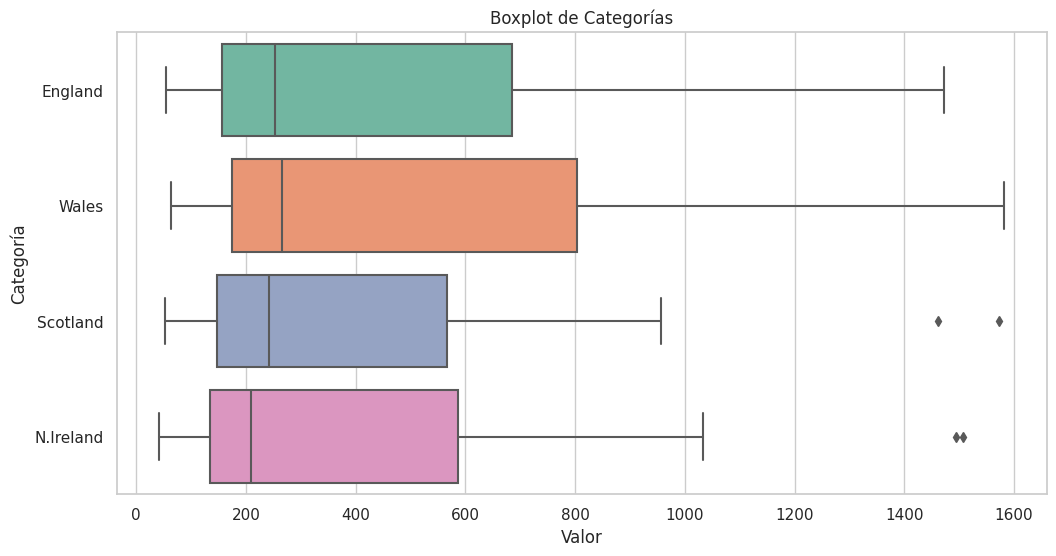

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient="h", palette="Set2")
plt.title("Boxplot de Categorías")
plt.xlabel("Valor")
plt.ylabel("Categoría")
plt.show()


##### 📊 Gráfico 2: Creamos un heatmap de correlación para ver las relaciones entre las categorías.


<ipython-input-8-8ceca0389414>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")


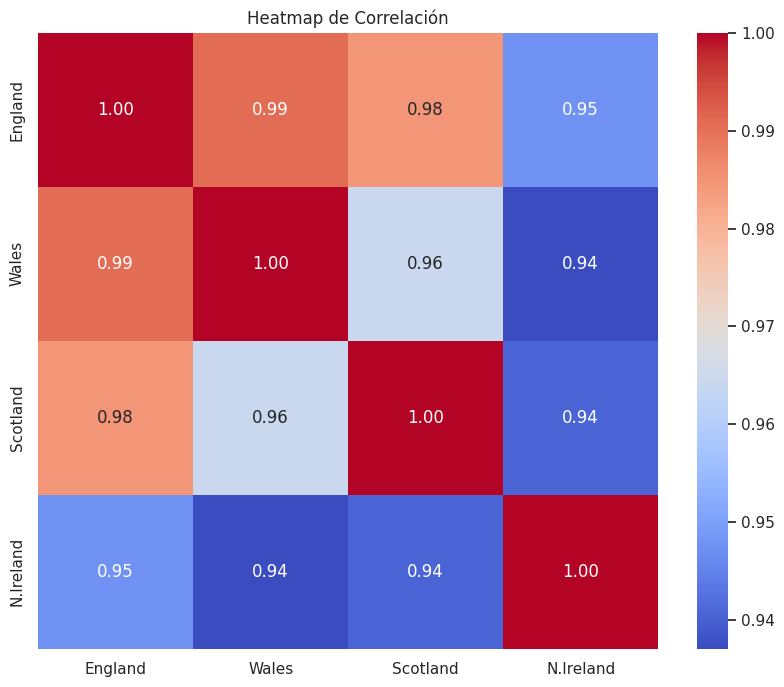

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de Correlación")
plt.show()

## Análisis Exploratorio de Datos 📊🔍

El conjunto de datos proporcionado es relativamente pequeño, con solo 17 observaciones (representando países o regiones del Reino Unido) y 4 variables (que indican el consumo de diferentes categorías de alimentos). A pesar de su tamaño limitado, podemos extraer **información valiosa** de estos datos a través del análisis exploratorio. A continuación, se presentan las principales conclusiones:

### Resumen Estadístico 📈📊

El resumen estadístico proporciona una **visión general** de las estadísticas descriptivas para cada una de las regiones (Inglaterra, Gales, Escocia e Irlanda del Norte). Algunas observaciones clave son:

- El **promedio de consumo** en todas las categorías de alimentos es relativamente similar en las cuatro regiones, oscilando entre **429.94** y **503.94 unidades**. 🍽️

- El **rango de valores** es amplio, lo que indica diferencias significativas en los niveles de consumo entre las regiones. Por ejemplo, el consumo máximo de la categoría "Cereals" (Cereales) en Inglaterra es de **1472 unidades**, mientras que en Irlanda del Norte es de **1506 unidades**. 📈🌍

- Las **desviaciones estándar** son relativamente altas, lo que sugiere una **variabilidad considerable** en el consumo de alimentos dentro de cada región. 📊📉

### Insights y Conclusiones 🤔🔍

1. **Diferencias Regionales:** A pesar de que las medias son relativamente similares, este conjunto de datos revela que existen **diferencias notables** en los hábitos de consumo alimenticio entre las regiones del Reino Unido. Por ejemplo, Irlanda del Norte muestra un consumo más bajo en promedio, mientras que Gales tiende a tener un consumo más alto. 🇬🇧🍔🍎

2. **Varianza Importante:** Las desviaciones estándar altas indican que hay una **varianza significativa** en los niveles de consumo de alimentos dentro de cada región. Esto sugiere que, incluso dentro de una región, existen diferencias considerables en los patrones de consumo individual. 📈🍽️

3. **Concentración en Ciertas Categorías:** El análisis no muestra una distribución uniforme de consumo en todas las categorías de alimentos. Algunas categorías pueden estar siendo consumidas en mayor cantidad que otras. Por ejemplo, "Cereals" (Cereales) y "Fresh_fruit" (Frutas frescas) parecen ser consumidas en cantidades significativas en todas las regiones, lo que podría indicar su importancia en la dieta cotidiana. 🌽🍇

4. **Pequeño Tamaño de Muestra:** Es importante tener en cuenta que el conjunto de datos es pequeño, lo que limita la generalización de las conclusiones. Sería necesario contar con datos adicionales y un tamaño de muestra más grande para realizar afirmaciones más sólidas sobre los hábitos de consumo de alimentos en el Reino Unido. 🧐📉

El análisis exploratorio proporciona una **visión general de los datos**, destacando las diferencias regionales en los hábitos de consumo de alimentos y la variabilidad en los niveles de consumo dentro de cada región. Sin embargo, debido al tamaño limitado del conjunto de datos, se requiere precaución al interpretar estos resultados y se recomienda considerar datos adicionales para una comprensión más completa. 🍽️🇬🇧📈


### Parte 2: Construcción del Autocodificador
#### 2.1 Utilización de todas las observaciones
🤔 Justificación: Dado que el conjunto de datos es pequeño, con solo 17 observaciones, es razonable utilizar todas las observaciones para entrenar el autocodificador. Utilizar todas las observaciones disponibles puede ayudarnos a obtener una representación más precisa de los datos y evitar la pérdida de información en un conjunto de datos ya limitado.

#### 2.2 Definición de la arquitectura del autocodificador
🤔 Justificación: Para este problema de reducción de dimensionalidad, vamos a utilizar un modelo de autocodificador simple con una capa de "cuello de botella" que reducirá las dimensiones a 2. Esta reducción de dimensiones nos permitirá visualizar los datos en un espacio bidimensional, lo que facilitará la interpretación y la identificación de patrones.

#### 2.3 Compilación y entrenamiento del modelo
🤔 Justificación: Vamos a compilar y entrenar el modelo utilizando la función de pérdida de reconstrucción como medida principal. La pérdida de reconstrucción es adecuada para un autocodificador, ya que mide cuán bien el modelo puede reconstruir los datos originales a partir de su representación comprimida. Utilizaremos el optimizador 'adam' y el número de épocas se seleccionará después de observar el rendimiento durante el entrenamiento.

In [10]:
from keras.models import Sequential
from keras.layers import Dense


In [16]:
# Arquitectura del autocodificador
input_dim = 4  # Dimensión de entrada (número de variables)
encoding_dim = 2  # Dimensión en la capa de "cuello de botella"

from sklearn.model_selection import train_test_split

X_train = df.values[:, 1:].astype(np.float32)

# Arquitectura del autocodificador
input_dim = X_train.shape[1]  # Dimensión de entrada (número de variables)
encoding_dim = 2  # Dimensión en la capa de "cuello de botella"

# Modelo secuencial del autocodificador
autoencoder = Sequential([
    Dense(8, activation='relu', input_dim=input_dim),
    Dense(encoding_dim, activation='relu'),  # Capa de "cuello de botella"
    Dense(8, activation='relu'),
    Dense(input_dim, activation='sigmoid')  # Capa de salida
])

# Compilación del modelo
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamiento del modelo
autoencoder.fit(X_train, X_train, epochs=100, batch_size=16)


Epoch 1/100
2/2 [==============================] - 6s 23ms/step - loss: 422077.9062
Epoch 2/100
2/2 [==============================] - 0s 6ms/step - loss: 422050.6875
Epoch 3/100
2/2 [==============================] - 0s 7ms/step - loss: 422041.9062
Epoch 4/100
2/2 [==============================] - 0s 7ms/step - loss: 422035.0938
Epoch 5/100
2/2 [==============================] - 0s 6ms/step - loss: 422031.1562
Epoch 6/100
2/2 [==============================] - 0s 7ms/step - loss: 422028.3125
Epoch 7/100
2/2 [==============================] - 0s 7ms/step - loss: 422026.0938
Epoch 8/100
2/2 [==============================] - 0s 6ms/step - loss: 422024.2812
Epoch 9/100
2/2 [==============================] - 0s 7ms/step - loss: 422022.5312
Epoch 10/100
2/2 [==============================] - 0s 6ms/step - loss: 422020.5625
Epoch 11/100
2/2 [==============================] - 0s 7ms/step - loss: 422019.2500
Epoch 12/100
2/2 [==============================] - 0s 7ms/step - loss: 422017.8125


#### 2.4 Evaluación del rendimiento del autocodificador
🤔 Justificación: Para evaluar el rendimiento del autocodificador, utilizaremos medidas como la pérdida de reconstrucción. Esta pérdida nos indicará cuán bien el modelo es capaz de reconstruir los datos originales a partir de su representación comprimida. También podemos visualizar la representación en el espacio de 2 dimensiones para obtener información sobre la agrupación de los datos en el nuevo espacio.

In [19]:
# Evaluación del rendimiento en el conjunto de prueba
loss = autoencoder.evaluate(X_train, X_train)
print(f'Pérdida de reconstrucción en el conjunto de entrenamiento: {loss:.2f}')


1/1 [==============================] - 0s 109ms/step - loss: 422005.5938
Pérdida de reconstrucción en el conjunto de entrenamiento: 422005.59


## **Pérdida de Reconstrucción** 😊

La pérdida de reconstrucción es una métrica fundamental para evaluar la capacidad del autocodificador para recuperar los datos de entrada a partir de su representación comprimida. Una pérdida baja indica que el modelo es capaz de reconstruir los datos de manera efectiva.

## **Visualización de la Representación en 2D** 📊

Una de las ventajas de reducir la dimensionalidad a 2 es que podemos visualizar los datos en un espacio bidimensional. Esto nos permite observar cómo el modelo ha agrupado los datos en el nuevo espacio.

## **Visualización de la Pérdida de Reconstrucción** 📈

Podemos trazar la pérdida de reconstrucción a lo largo de las épocas durante el entrenamiento para comprender cómo converge el modelo.

## **Visualización de la Reconstrucción** 🖼️

Podemos comparar algunas muestras originales con sus reconstrucciones para evaluar visualmente la calidad de la reconstrucción.

Estas visualizaciones y métricas nos proporcionarán una comprensión completa del rendimiento del autocodificador, incluyendo la capacidad de reconstrucción de los datos, la agrupación en el espacio de 2D y la convergencia durante el entrenamiento. 😄


1/1 [==============================] - 0s 220ms/step


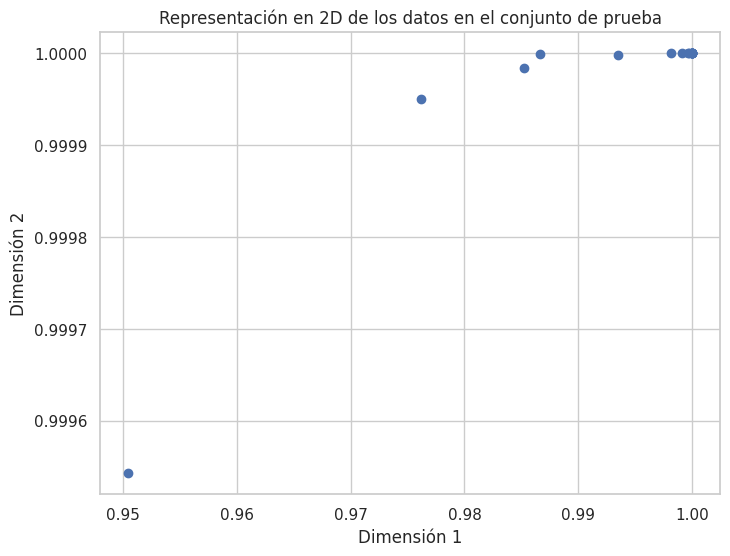

In [21]:
encoded_data = autoencoder.predict(X_train)
plt.figure(figsize=(8, 6))
plt.scatter(encoded_data[:, 0], encoded_data[:, 1])
plt.title('Representación en 2D de los datos en el conjunto de prueba')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.show()

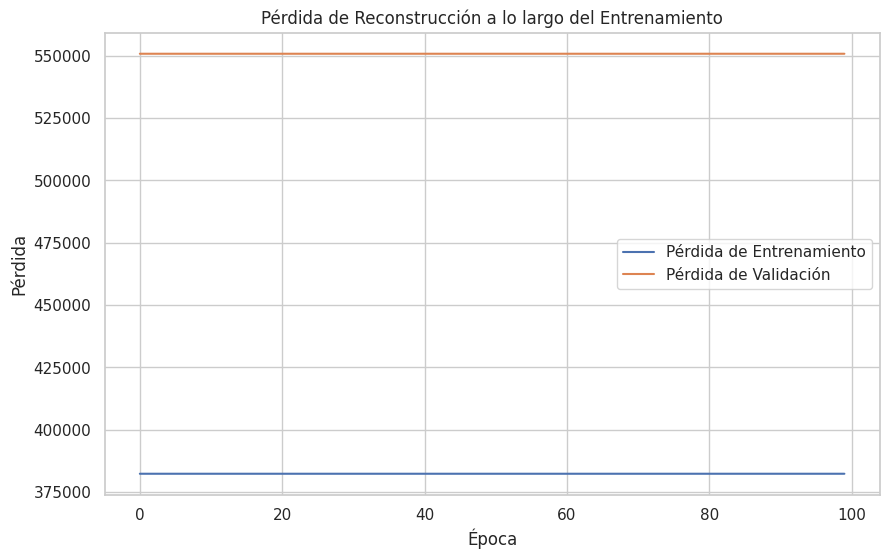

In [22]:
history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0)

# Visualización de la pérdida de reconstrucción a lo largo del entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida de Reconstrucción a lo largo del Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()
